In [2]:
import numpy as np
from numpy import round
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
alpha = 1.

def gamma_k(_kx, _ky):
    return (np.cos(_kx) + np.cos(_ky))/2

def gamma2_k(_kx, _ky):
    return 1/4 * (np.cos(_kx) + np.cos(_ky))**2

def a_func(t, n, delta = 1., lamb = 0.):
    return 2 * (delta + t - alpha * 2 * n * (t/2 + lamb * delta))

def b_func(t, n, I, delta = 1., lamb = 0.):
    return 2 * (1 - 2 * n + I + alpha * t * (t/2 + lamb * delta) )

def get_bog_pars(t, n, I, _kx, _ky, delta = 1., lamb = 0.):
    a = a_func(t, n, delta, lamb)
    b = b_func(t, n, I, delta, lamb)

    wk = np.abs(np.sqrt(a**2 - b**2 * gamma2_k(_kx, _ky) + 0j))
    
    alpha_plus = np.sqrt(1/2 * (a/wk + 1) + 0j)
    alpha_minus = np.sign(gamma_k(_kx, _ky)) * np.sqrt(1/2 * (a/wk - 1) + 0j)

    return a, b, wk, alpha_plus, alpha_minus

def t(b, wk, gamma2k, N):
    return np.abs(b)/N * np.real(np.sum(gamma2k / wk))

def n(a, wk, N):
    return 1/(2*N) * np.sum(np.abs(a/wk - 1))

def I(a_plus_k, a_minus_k, a_plus_q, a_minus_q, kx, ky, qx, qy, N):
    return 1/(2*N**2) * np.sum(np.real(a_plus_k * a_minus_k * np.conj(a_plus_q * a_minus_q)) * 2 * gamma_k(kx + qx, ky + qy)
                         + (np.abs(a_minus_k)**2 * np.abs(a_plus_q)**2) * 2 * gamma_k(kx - qx, ky - qy))

In [4]:
def SC_MF(delta = 1., lamb = 0., leapfrog : bool = False, k_bins = 50, n_steps = 10, disable_tqdm = False):
    # strating parameters
    n_old = .25
    t_old = .62
    I_old = .07
    #print(n_old, t_old, I_old)

    N = k_bins**2
    k = np.linspace(-np.pi, np.pi, k_bins, endpoint = False)

    px, py = np.meshgrid(k, k, indexing = 'ij')
    kx, ky, qx, qy = np.meshgrid(k, k, k, k, indexing = 'ij')

    t_array = []
    n_array = []
    I_array = []

    CHI = .25

    for _ in tqdm(range(n_steps), disable = disable_tqdm):
        # get general parameters
        a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, px, py, delta, lamb)
        gamma2k = gamma2_k(px, py)

        # get new t
        t_new = t(b, wk, gamma2k, N)

        # if leapfrog -> update t and delta_k
        if leapfrog:
            t_old = CHI * t_new + (1 - CHI) * t_old
            a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, px, py, delta, lamb)

        # get new n
        n_new = n(a, wk, N)

        # if leapfrog -> update n
        if leapfrog:
            n_old = CHI * n_new + (1 - CHI) * n_old

        # to satisfy both methods, it is better to calculate q here
        a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, kx, ky, delta, lamb)
        a, b, wq, apq, amq = get_bog_pars(t_old, n_old, I_old, qx, qy, delta, lamb)

        # get new I
        I_new = I(apk, amk, apq, amq, kx, ky, qx, qy, N)

        if not leapfrog:
            t_old = CHI * t_new + (1 - CHI) * t_old
            n_old = CHI * n_new + (1 - CHI) * n_old
        I_old = CHI * I_new + (1 - CHI) * I_old

        t_array.append(t_old)
        n_array.append(n_old)
        I_array.append(I_old)
        
    return np.array(t_array), np.array(n_array), np.array(I_array), range(n_steps)

In [5]:
def disp(n, t, I, delta = 1., l = 0., _print = True):

    ak = a_func(t, n, delta, l)
    bk = b_func(t, n, I, delta, l)

    #print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')

    const = 0.

    if bk**2 > ak**2:
        if _print:
            print('IMAGINARY')
        const = 0j
    
    gap_g = np.sqrt(np.abs(ak)**2 - np.abs(bk)**2 + const)
    gap_x = np.sqrt(np.abs(ak)**2)

    if _print:
        print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')
        print(f'Gap at G point: {round(gap_g, 3)}')
        print(f'Gap at X point: {round(gap_x, 3)}')

    return gap_g, gap_x

In [6]:
def get_mf(delta = 1., lamb = 0., k_bins = 50, froggie = True, plot_changes : bool = False, n_steps = 20, _print = True):
    ts, ns, Is, steps = SC_MF(delta, lamb, leapfrog=froggie, k_bins=k_bins, n_steps = n_steps, disable_tqdm = not _print)
    fin_t = ts[-1]
    fin_n = ns[-1]
    fin_I = Is[-1]

    if _print:
        print(f'Final t = {round(fin_t, 5)}')
        print(f'Final n = {round(fin_n, 5)}')
        print(f'Approximate final I = {round(fin_t**2/4 + fin_n**2, 5)}')
        print(f'Final I = {round(fin_I, 5)}')

    if plot_changes:
        plt.scatter(steps[1:], abs(ts[1:] - np.roll(ts[:-1], 1)), label = 't')
        plt.scatter(steps[1:], abs(ns[1:] - np.roll(ns[:-1], 1)), label = 'n')
        plt.scatter(steps[1:], abs(Is[1:] - np.roll(Is[:-1], 1)), label = 'I')
        plt.yscale('log')
        plt.legend()
        plt.show()

    return disp(fin_n, fin_t, fin_I, delta, lamb, _print = _print)

100%|██████████| 100/100 [03:39<00:00,  2.20s/it]

Final t = 0.67843
Final n = 0.24945
Approximate final I = 0.17729
Final I = 0.07079


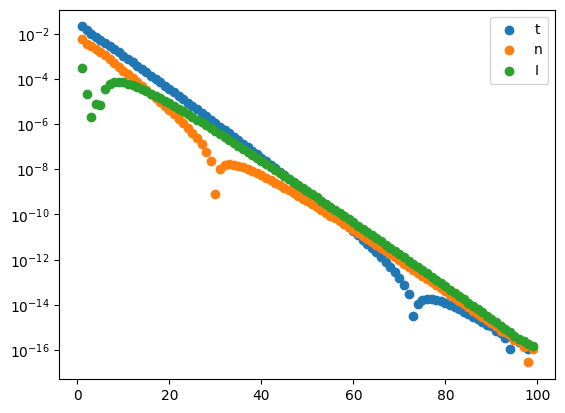

IMAGINARY
Ak = 2.02059, Bk = 2.96091
Gap at G point: 2.164j
Gap at X point: 2.021


100%|██████████| 100/100 [03:45<00:00,  2.26s/it]

Final t = 0.70806
Final n = 0.27491
Approximate final I = 0.20091
Final I = 0.11385


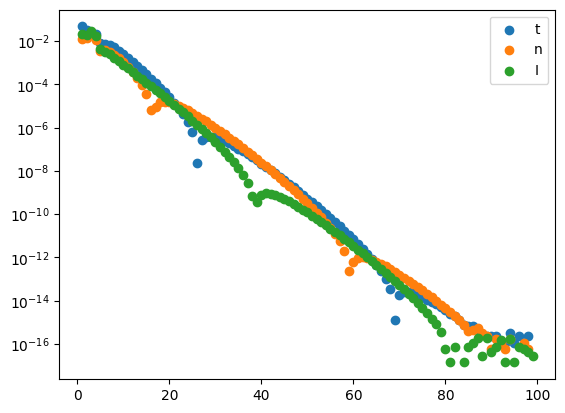

IMAGINARY
Ak = 2.25705, Bk = 2.62068
Gap at G point: 1.332j
Gap at X point: 2.257


100%|██████████| 100/100 [03:41<00:00,  2.21s/it]

Final t = 0.31414
Final n = 0.08213
Approximate final I = 0.03142
Final I = 0.02467


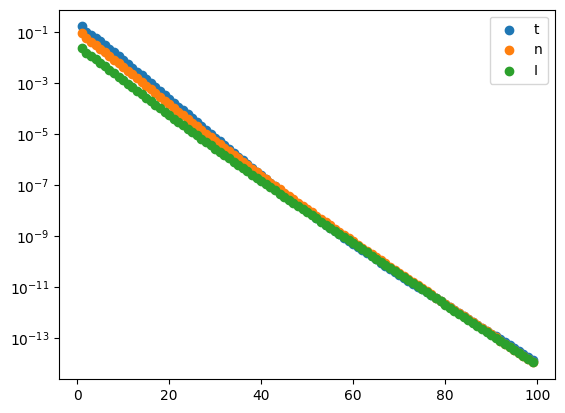

Ak = 2.41242, Bk = 2.13365
Gap at G point: 1.126
Gap at X point: 2.412


(np.float64(1.1257463334164146), np.float64(2.412419277247495))

In [7]:
#get_mf(1., 0., k_bins = 50)
get_mf(1., 1., k_bins = 75, n_steps = 100, plot_changes = True)
get_mf(1., .7, k_bins = 75, n_steps = 100, plot_changes = True)
get_mf(1., .5, k_bins = 75, n_steps = 100, plot_changes = True)
#get_mf(1.44, 0., k_bins = 50)
#get_mf(2., 0., k_bins = 50)
#get_mf(1., 1., k_bins = 50, n_steps = 20, plot_changes=True)
#print()
#get_mf(1.44, 0., k_bins = 50)
#get_mf(1.44, 1., k_bins = 50)
#print()
#get_mf(2., 0., k_bins = 50)
#get_mf(2., 1., k_bins = 50)